In [1]:
!pip install -q scikit-learn tensorflow joblib nltk Sastrawi tqdm pandas numpy matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.9 MB/s eta 0:00:00


In [2]:
import os
import json
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_score, recall_score, f1_score)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, LSTM, GRU, Bidirectional,
                                      Dense, Dropout, SpatialDropout1D)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

os.makedirs('models', exist_ok=True)
print("Import selesai.")
print(f"TensorFlow version: {tf.__version__}")

Import selesai.
TensorFlow version: 2.20.0


In [3]:
df = pd.read_csv('/content/data/final_reviews_new_sakpole.csv')
print(f"Shape: {df.shape}")
print(df['sentiment'].value_counts())
df.head(3)

Shape: (17188, 8)
sentiment
negative    7834
positive    7098
neutral     2256
Name: count, dtype: int64


,content,clean_text,sentiment_score,sentiment,score,at,userName,thumbsUpCount
0,Aplikasi bermasalah.Error saat mau masuk menu ...,aplikasi masalah ganggu masuk menu bayar kali ...,5,positive,1,2026-04-17 12:59:26,Pengguna Google,10
1,aplikasi membantu cek brp pembayaran pajaknya....,aplikasi bantu cek brp bayar pajak saran bayar...,-8,negative,5,2026-05-20 11:17:50,Pengguna Google,0
2,kenapa blm masuk juga padahal suda bayar Lo in...,blm masuk suda bayar tolong tindak lanjut baya...,5,positive,1,2026-05-15 20:49:39,Pengguna Google,2


In [4]:
# Hapus baris dengan clean_text kosong atau sentiment kosong
df = df.dropna(subset=['clean_text', 'sentiment'])
df = df[df['clean_text'].str.strip() != ''].reset_index(drop=True)

# Filter teks terlalu pendek (kurang dari 2 kata)
df = df[df['clean_text'].apply(lambda x: len(str(x).split()) >= 2)].reset_index(drop=True)

print(f"Total data setelah filter: {len(df)}")
print(df['sentiment'].value_counts())

Total data setelah filter: 13287
sentiment
negative    7229
positive    4902
neutral     1156
Name: count, dtype: int64


In [5]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])

print("Mapping label:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} -> {cls}")

NUM_CLASSES = len(le.classes_)
print(f"\nJumlah kelas: {NUM_CLASSES}")

Mapping label:
  0 -> negative
  1 -> neutral
  2 -> positive

Jumlah kelas: 3


In [6]:
X = df['clean_text'].astype(str)
y = df['label']

X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f"Train: {len(X_train1)} | Test: {len(X_test1)}")

Train: 10629 | Test: 2658


In [7]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train1_tfidf = tfidf.fit_transform(X_train1)
X_test1_tfidf  = tfidf.transform(X_test1)
print(f"TF-IDF shape train: {X_train1_tfidf.shape}")

TF-IDF shape train: (10629, 10000)


In [8]:
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    C=1.0,
    solver='lbfgs',
    multi_class='multinomial',
    random_state=SEED
)
lr_model.fit(X_train1_tfidf, y_train1)

train_acc1 = accuracy_score(y_train1, lr_model.predict(X_train1_tfidf))
y_pred1    = lr_model.predict(X_test1_tfidf)
test_acc1  = accuracy_score(y_test1, y_pred1)

print(f"Train Accuracy : {train_acc1:.4f}")
print(f"Test  Accuracy : {test_acc1:.4f}")
print()
print(classification_report(y_test1, y_pred1, target_names=le.classes_))

Train Accuracy : 0.9379
Test  Accuracy : 0.8661

              precision    recall  f1-score   support

    negative       0.94      0.89      0.91      1446
     neutral       0.49      0.67      0.57       231
    positive       0.88      0.88      0.88       981

    accuracy                           0.87      2658
   macro avg       0.77      0.81      0.79      2658
weighted avg       0.88      0.87      0.87      2658



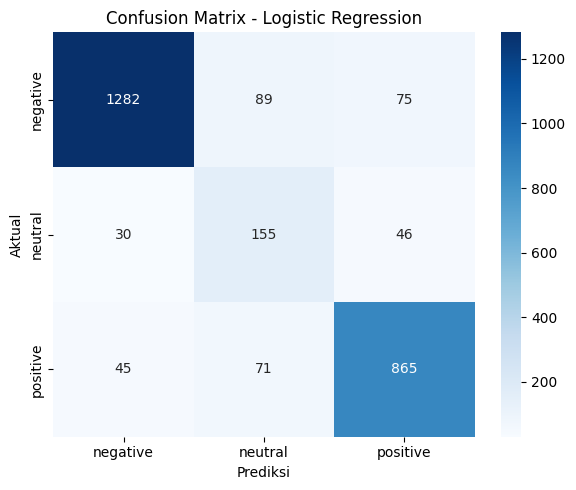

In [10]:
cm1 = confusion_matrix(y_test1, y_pred1)
plt.figure(figsize=(6, 5))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.tight_layout()
plt.savefig('/content/visualizations/cm_logreg.png', dpi=100)
plt.show()

In [12]:
# Simpan artefak Skema 1
joblib.dump(lr_model, 'models/skema1/model_logreg.joblib')
joblib.dump(tfidf,    'models/skema1/vectorizer_tfidf.joblib')
joblib.dump(le,       'models/skema1/label_encoder.joblib')
print("Artefak Skema 1 tersimpan.")

Artefak Skema 1 tersimpan.


BiLSTM 80/20

In [13]:
MAX_FEATURES = 10000
MAX_LEN      = 50
EMBED_DIM    = 128
BATCH_SIZE   = 512
EPOCHS       = 20

X2 = df['clean_text'].astype(str).values
y2 = df['label'].values

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=SEED, stratify=y2
)
print(f"Train: {len(X_train2)} | Test: {len(X_test2)}")

Train: 10629 | Test: 2658


In [14]:
tokenizer = Tokenizer(num_words=MAX_FEATURES, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train2)

X_train2_seq = pad_sequences(tokenizer.texts_to_sequences(X_train2), maxlen=MAX_LEN, padding='post', truncating='post')
X_test2_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test2),  maxlen=MAX_LEN, padding='post', truncating='post')

y_train2_cat = to_categorical(y_train2, NUM_CLASSES)
y_test2_cat  = to_categorical(y_test2,  NUM_CLASSES)

print(f"Sequence shape train: {X_train2_seq.shape}")

Sequence shape train: (10629, 50)


In [15]:
def build_bilstm(vocab_size, embed_dim, max_len, num_classes):
    model = Sequential([
        Embedding(vocab_size, embed_dim, input_length=max_len),
        SpatialDropout1D(0.3),
        Bidirectional(LSTM(128, return_sequences=True)),
        Bidirectional(LSTM(64)),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

bilstm_model = build_bilstm(MAX_FEATURES + 1, EMBED_DIM, MAX_LEN, NUM_CLASSES)
bilstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
callbacks2 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)
]

history2 = bilstm_model.fit(
    X_train2_seq, y_train2_cat,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks2,
    verbose=1
)

Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.5202 - loss: 0.9524 - val_accuracy: 0.5748 - val_loss: 0.8496 - learning_rate: 0.0010
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.6974 - loss: 0.7517 - val_accuracy: 0.7883 - val_loss: 0.5401 - learning_rate: 0.0010
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.8255 - loss: 0.4825 - val_accuracy: 0.8627 - val_loss: 0.4047 - learning_rate: 0.0010
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.8881 - loss: 0.3212 - val_accuracy: 0.8777 - val_loss: 0.3700 - learning_rate: 0.0010
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.9169 - loss: 0.2395 - val_accuracy: 0.8909 - val_loss: 0.3314 - learning_rate: 0.0010
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.9451 - loss: 0.1648 - val_accuracy: 0.8777 - val_loss: 0.3869 - learning_rate: 0.0010
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.9493 - loss: 0.1370 - val_accuracy: 

In [17]:
train_loss2, train_acc2 = bilstm_model.evaluate(X_train2_seq, y_train2_cat, verbose=0)
test_loss2,  test_acc2  = bilstm_model.evaluate(X_test2_seq,  y_test2_cat,  verbose=0)

y_pred2 = np.argmax(bilstm_model.predict(X_test2_seq, verbose=0), axis=1)

print(f"Train Accuracy : {train_acc2:.4f}")
print(f"Test  Accuracy : {test_acc2:.4f}")
print()
print(classification_report(y_test2, y_pred2, target_names=le.classes_))

Train Accuracy : 0.9441
Test  Accuracy : 0.9029

              precision    recall  f1-score   support

    negative       0.92      0.96      0.94      1446
     neutral       0.69      0.53      0.60       231
    positive       0.92      0.91      0.91       981

    accuracy                           0.90      2658
   macro avg       0.84      0.80      0.82      2658
weighted avg       0.90      0.90      0.90      2658



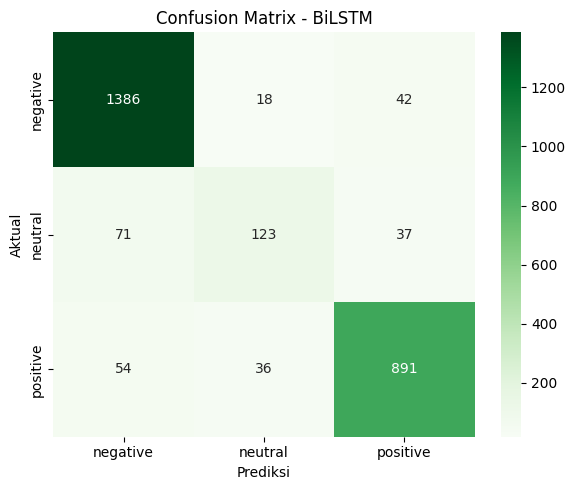

In [18]:
cm2 = confusion_matrix(y_test2, y_pred2)
plt.figure(figsize=(6, 5))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - BiLSTM')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.tight_layout()
plt.savefig('/content/visualizations/cm_bilstm.png', dpi=100)
plt.show()

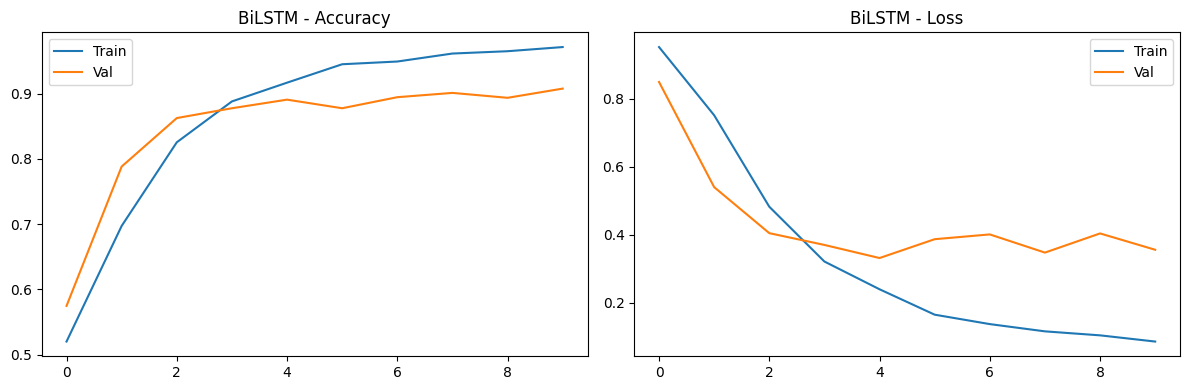

In [19]:
# Plot training history BiLSTM
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history2.history['accuracy'], label='Train')
axes[0].plot(history2.history['val_accuracy'], label='Val')
axes[0].set_title('BiLSTM - Accuracy')
axes[0].legend()
axes[1].plot(history2.history['loss'], label='Train')
axes[1].plot(history2.history['val_loss'], label='Val')
axes[1].set_title('BiLSTM - Loss')
axes[1].legend()
plt.tight_layout()
plt.savefig('/content/visualizations/history_bilstm.png', dpi=100)
plt.show()

In [20]:
bilstm_model.save('/content/models/skema2/model_bilstm.keras')
with open('/content/models/skema2/tokenizer_bilstm.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("Artefak Skema 2 tersimpan.")

Artefak Skema 2 tersimpan.


Skema 3 - BiGRU

In [21]:
X3 = df['clean_text'].astype(str).values
y3 = df['label'].values

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X3, y3, test_size=0.3, random_state=SEED, stratify=y3
)
print(f"Train: {len(X_train3)} | Test: {len(X_test3)}")

Train: 9300 | Test: 3987


In [22]:
tokenizer3 = Tokenizer(num_words=MAX_FEATURES, oov_token='<OOV>')
tokenizer3.fit_on_texts(X_train3)

X_train3_seq = pad_sequences(tokenizer3.texts_to_sequences(X_train3), maxlen=MAX_LEN, padding='post', truncating='post')
X_test3_seq  = pad_sequences(tokenizer3.texts_to_sequences(X_test3),  maxlen=MAX_LEN, padding='post', truncating='post')

y_train3_cat = to_categorical(y_train3, NUM_CLASSES)
y_test3_cat  = to_categorical(y_test3,  NUM_CLASSES)

print(f"Sequence shape train: {X_train3_seq.shape}")

Sequence shape train: (9300, 50)


In [23]:
def build_bigru(vocab_size, embed_dim, max_len, num_classes):
    model = Sequential([
        Embedding(vocab_size, embed_dim, input_length=max_len),
        SpatialDropout1D(0.3),
        Bidirectional(GRU(128, return_sequences=True)),
        Bidirectional(GRU(64)),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

bigru_model = build_bigru(MAX_FEATURES + 1, EMBED_DIM, MAX_LEN, NUM_CLASSES)
bigru_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
callbacks3 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)
]

history3 = bigru_model.fit(
    X_train3_seq, y_train3_cat,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks3,
    verbose=1
)

Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.5589 - loss: 0.9243 - val_accuracy: 0.7129 - val_loss: 0.7453 - learning_rate: 0.0010
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.7705 - loss: 0.6183 - val_accuracy: 0.7903 - val_loss: 0.5259 - learning_rate: 0.0010
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.8538 - loss: 0.4115 - val_accuracy: 0.8129 - val_loss: 0.4860 - learning_rate: 0.0010
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.9002 - loss: 0.2771 - val_accuracy: 0.8763 - val_loss: 0.4038 - learning_rate: 0.0010
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.9372 - loss: 0.1881 - val_accuracy: 0.8839 - val_loss: 0.3624 - learning_rate: 0.0010
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.9535 - loss: 0.1385 - val_accuracy: 0.8925 - val_loss: 0.3742 - learning_rate: 0.0010
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.9588 - loss: 0.1180 - val_accuracy: 

In [25]:
train_loss3, train_acc3 = bigru_model.evaluate(X_train3_seq, y_train3_cat, verbose=0)
test_loss3,  test_acc3  = bigru_model.evaluate(X_test3_seq,  y_test3_cat,  verbose=0)

y_pred3 = np.argmax(bigru_model.predict(X_test3_seq, verbose=0), axis=1)

print(f"Train Accuracy : {train_acc3:.4f}")
print(f"Test  Accuracy : {test_acc3:.4f}")
print()
print(classification_report(y_test3, y_pred3, target_names=le.classes_))

Train Accuracy : 0.9516
Test  Accuracy : 0.9054

              precision    recall  f1-score   support

    negative       0.95      0.94      0.94      2169
     neutral       0.71      0.58      0.64       347
    positive       0.88      0.93      0.91      1471

    accuracy                           0.91      3987
   macro avg       0.85      0.82      0.83      3987
weighted avg       0.90      0.91      0.90      3987



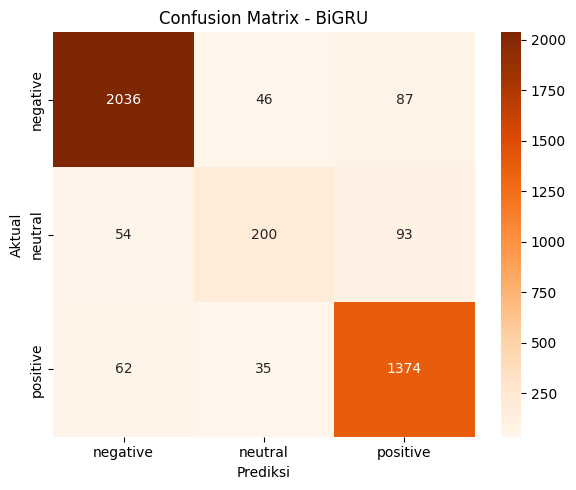

In [26]:
cm3 = confusion_matrix(y_test3, y_pred3)
plt.figure(figsize=(6, 5))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - BiGRU')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.tight_layout()
plt.savefig('/content/visualizations/cm_bigru.png', dpi=100)
plt.show()

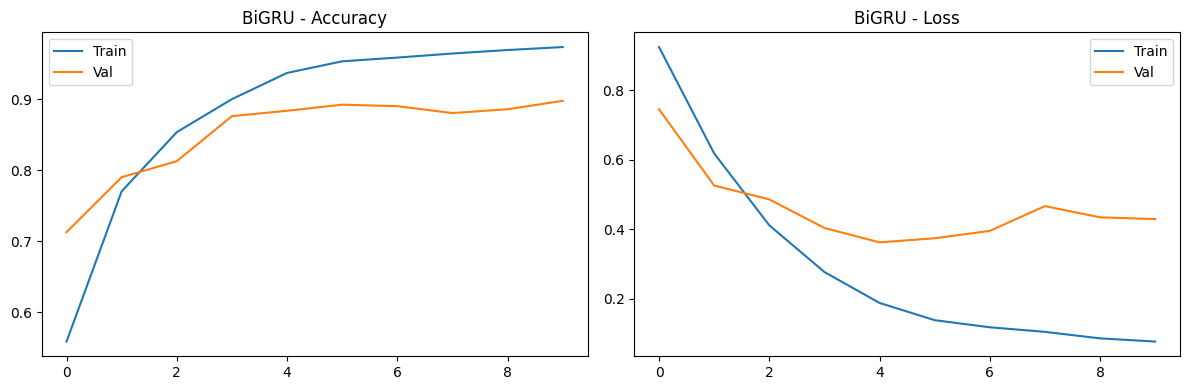

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history3.history['accuracy'], label='Train')
axes[0].plot(history3.history['val_accuracy'], label='Val')
axes[0].set_title('BiGRU - Accuracy')
axes[0].legend()
axes[1].plot(history3.history['loss'], label='Train')
axes[1].plot(history3.history['val_loss'], label='Val')
axes[1].set_title('BiGRU - Loss')
axes[1].legend()
plt.tight_layout()
plt.savefig('/content/visualizations/history_bigru.png', dpi=100)
plt.show()

In [28]:
bigru_model.save('/content/models/skema3/model_bigru.keras')
with open('/content/models/skema3/tokenizer_bigru.pkl', 'wb') as f:
    pickle.dump(tokenizer3, f)
print("Artefak Skema 3 tersimpan.")

Artefak Skema 3 tersimpan.


Perbandingan Model

In [29]:
def get_metrics(y_true, y_pred):
    return {
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro':    recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_macro':        f1_score(y_true, y_pred, average='macro', zero_division=0),
    }

m1 = get_metrics(y_test1, y_pred1)
m2 = get_metrics(y_test2, y_pred2)
m3 = get_metrics(y_test3, y_pred3)

comparison = pd.DataFrame([
    {
        'scheme': 'Skema 1',
        'feature_extraction': 'TF-IDF',
        'model': 'Logistic Regression',
        'split': '80/20',
        'train_accuracy': round(train_acc1, 4),
        'test_accuracy':  round(test_acc1, 4),
        'precision_macro': round(m1['precision_macro'], 4),
        'recall_macro':    round(m1['recall_macro'], 4),
        'f1_macro':        round(m1['f1_macro'], 4),
    },
    {
        'scheme': 'Skema 2',
        'feature_extraction': 'Tokenizer + Padding',
        'model': 'BiLSTM',
        'split': '80/20',
        'train_accuracy': round(train_acc2, 4),
        'test_accuracy':  round(test_acc2, 4),
        'precision_macro': round(m2['precision_macro'], 4),
        'recall_macro':    round(m2['recall_macro'], 4),
        'f1_macro':        round(m2['f1_macro'], 4),
    },
    {
        'scheme': 'Skema 3',
        'feature_extraction': 'Tokenizer + Padding',
        'model': 'BiGRU',
        'split': '70/30',
        'train_accuracy': round(train_acc3, 4),
        'test_accuracy':  round(test_acc3, 4),
        'precision_macro': round(m3['precision_macro'], 4),
        'recall_macro':    round(m3['recall_macro'], 4),
        'f1_macro':        round(m3['f1_macro'], 4),
    },
])

print(comparison.to_string(index=False))

 scheme  feature_extraction               model split  train_accuracy  test_accuracy  precision_macro  recall_macro  f1_macro
Skema 1              TF-IDF Logistic Regression 80/20          0.9379         0.8661           0.7714        0.8131    0.7873
Skema 2 Tokenizer + Padding              BiLSTM 80/20          0.9441         0.9029           0.8436        0.7997    0.8179
Skema 3 Tokenizer + Padding               BiGRU 70/30          0.9516         0.9054           0.8473        0.8164    0.8292


In [30]:
# Pilih model terbaik berdasarkan test_accuracy + f1_macro
comparison['score'] = comparison['test_accuracy'] + comparison['f1_macro']
best_row = comparison.loc[comparison['score'].idxmax()]
print(f"\nModel terbaik: {best_row['model']} (Skema: {best_row['scheme']})")
print(f"  Test Accuracy : {best_row['test_accuracy']}")
print(f"  F1 Macro      : {best_row['f1_macro']}")


Model terbaik: BiGRU (Skema: Skema 3)
  Test Accuracy : 0.9054
  F1 Macro      : 0.8292


In [31]:
import shutil

best_model_name = best_row['model']

# Salin model terbaik sebagai best_model
if best_model_name == 'Logistic Regression':
    shutil.copy('/content/models/skema1/model_logreg.joblib', '/content/models/best_model.joblib')
    best_type = 'ml'
    best_artifacts = [
        '/content/models/best_model.joblib',
        '/content/models/skema1/vectorizer_tfidf.joblib',
        '/content/models/label_encoder.joblib'
    ]

elif best_model_name == 'BiLSTM':
    shutil.copy('/content/models/skema2/model_bilstm.keras', '/content/models/best_model.keras')
    shutil.copy('/content/models/skema2/tokenizer_bilstm.pkl', '/content/models/tokenizer_best.pkl')
    best_type = 'dl'
    best_artifacts = [
        '/content/models/best_model.keras',
        '/content/models/tokenizer_best.pkl',
        '/content/models/label_encoder.joblib'
    ]

else:
    shutil.copy('/content/models/skema3/model_bigru.keras', '/content/models/best_model.keras')
    shutil.copy('/content/models/skema3/tokenizer_bigru.pkl', '/content/models/tokenizer_best.pkl')
    best_type = 'dl'
    best_artifacts = [
        '/content/models/best_model.keras',
        '/content/models/tokenizer_best.pkl',
        '/content/models/label_encoder.joblib'
    ]

# Simpan label encoder jika belum
joblib.dump(le, '/content/models/label_encoder.joblib')

# Simpan config
config = {'max_features': MAX_FEATURES, 'max_len': MAX_LEN, 'embed_dim': EMBED_DIM}
with open('/content/models/dl_config.json', 'w') as f:
    json.dump(config, f)

# Simpan metadata
metadata = {
    'best_model_name': best_model_name,
    'best_model_type': best_type,
    'test_accuracy': float(best_row['test_accuracy']),
    'f1_macro': float(best_row['f1_macro']),
    'labels': le.classes_.tolist(),
    'num_classes': int(NUM_CLASSES),
    'preprocessing_notes': 'clean_text dari 02_eda_cleaning_labeling.ipynb',
    'required_artifacts': best_artifacts,
    'dl_config': config if best_type == 'dl' else {}
}

with open('/content/models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Metadata tersimpan di /content/models/model_metadata.json")
print(json.dumps(metadata, indent=2))

Metadata tersimpan di /content/models/model_metadata.json
{
  "best_model_name": "BiGRU",
  "best_model_type": "dl",
  "test_accuracy": 0.9054,
  "f1_macro": 0.8292,
  "labels": [
    "negative",
    "neutral",
    "positive"
  ],
  "num_classes": 3,
  "preprocessing_notes": "clean_text dari 02_eda_cleaning_labeling.ipynb",
  "required_artifacts": [
    "/content/models/best_model.keras",
    "/content/models/tokenizer_best.pkl",
    "/content/models/label_encoder.joblib"
  ],
  "dl_config": {
    "max_features": 10000,
    "max_len": 50,
    "embed_dim": 128
  }
}


In [32]:
!zip -r /content/project.zip /content/

  adding: content/ (stored 0%)
  adding: content/.config/ (stored 0%)
  adding: content/.config/gce (stored 0%)
  adding: content/.config/.last_survey_prompt.yaml (stored 0%)
  adding: content/.config/.last_update_check.json (deflated 22%)
  adding: content/.config/config_sentinel (stored 0%)
  adding: content/.config/active_config (stored 0%)
  adding: content/.config/configurations/ (stored 0%)
  adding: content/.config/configurations/config_default (deflated 15%)
  adding: content/.config/default_configs.db (deflated 98%)
  adding: content/.config/.last_opt_in_prompt.yaml (stored 0%)
  adding: content/.config/logs/ (stored 0%)
  adding: content/.config/logs/2026.05.21/ (stored 0%)
  adding: content/.config/logs/2026.05.21/13.26.27.601334.log (deflated 58%)
  adding: content/.config/logs/2026.05.21/13.26.44.509737.log (deflated 58%)
  adding: content/.config/logs/2026.05.21/13.26.07.261908.log (deflated 92%)
  adding: content/.config/logs/2026.05.21/13.26.59.793897.log (deflated 56%)